In [1]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import scipy.stats as stats
import matplotlib.pyplot as plt

import os
os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
print(os.getcwd())

G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


## 1. DATA preprocessing

In [2]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
gauge_info['Period_length']=gauge_info['Expected_entries']/365

# Final criteria
yr_strt=1985;yr_end=2012
period=yr_end-yr_strt; miss_prc=8
gauge_final=gauge_info.loc[(gauge_info['Period_length']>period) & (gauge_info['missing_percent']<miss_prc)]
gauge_final.reset_index(drop=True,inplace=True)

stn=gauge_final['GaugeID'].values[35]

for g,stn in enumerate(gauge_final['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True) 
    nan_years = data1.groupby(data1.index.year)['Streamflow (cumecs)'].apply(lambda x: x.isna().all())
    nan_years=nan_years[nan_years].index.to_list()
    data1=data1.interpolate(method='linear')
    data1.to_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv') 
    



# 2. Poisson tests - To check if there is clustering in a station

In [506]:
gauge_final=gauge_final[["GaugeID","Station","Latitude","Longitude"]]
station=gauge_final['Station']
threshold=[85,90,95,97,99,99.5]
window_n = [1,2,3,4,5]  
window_starts = pd.date_range(start="1970", end=pd.to_datetime('2022')-pd.DateOffset(years=m), freq=pd.DateOffset(years=step))

data=np.full((len(station),len(threshold),len(window_n)),np.nan)

result = xr.Dataset(
    {
        'Chisquare': (['station','threshold','window'], data),
        'KS': (['station','threshold','window'], data),
        'Dispersion': (['station','threshold','window'], data)
    },
    coords={
        'station': station,
        'threshold': threshold,
        'window': window_n
    })


results_array = np.full((3,len(station), len(threshold), len(window_n)), np.nan)


In [509]:
 for s,stn in enumerate(station):

    #stn=station[3]
    gauge=gauge_final.loc[s,'GaugeID']
    data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{gauge}.csv',index_col=0,parse_dates=True) 
    
    for t,thr in enumerate(threshold):
    
        POT=data1[data1['Streamflow (cumecs)']>np.percentile(data1['Streamflow (cumecs)'],thr)]

        #Independent Criteria 
        IC=pd.Timedelta(days=15)
        POT=POT[POT.index.to_series().diff().fillna(pd.Timedelta(days=50)) > IC]

        # Assing binary values
        data1['Indicator'] = data1.index.isin(POT.index).astype(int)

        for w,wnd in enumerate(window_n):

            # Calculating total event in the timewindow
            flood_count=data1['Indicator'].resample(f'{wnd}A').sum()
            # Estimate Poisson parameter (λ) as the mean
            lambda_hat = flood_count.mean()

            
            # 1. Chisquare test 
            
            x = np.arange(0, flood_count.max() + 1)  # Possible flood counts
            poisson_pmf = stats.poisson.pmf(x, lambda_hat) * len(flood_count)  # Scale by sample size

            obs_freq, bins = np.histogram(flood_count, bins=np.arange(0, flood_count.max() + 2)-0.5)  # Get observed frequencies
            
            exp_freq = stats.poisson.pmf(x, lambda_hat)* len(flood_count)  # S# Get expected Poisson frequencies
            exp_freq *= sum(obs_freq) / sum(exp_freq)  # Normalize to ensure total counts match

            chi2_stat, p_value = stats.chisquare(obs_freq, exp_freq)


            # 2 Dispersion TEst
            variance = flood_count.var()
            dispersion_ratio = variance / lambda_hat


            # 3 KS Test
            def ecdf(data):
                sorted_data = np.sort(data)
                cdf_values = np.arange(1, len(data) + 1) / len(data)
                return sorted_data, cdf_values

            x_ecdf, y_ecdf = ecdf(flood_count)
            D, p_ks = stats.kstest(flood_count, stats.poisson.cdf, args=(lambda_hat,))


            # Store results in NumPy array
            results_array[0,s,t,w] = p_value  # Chi-square p-value
            results_array[1,s,t,w] = p_ks  # KS p-value
            results_array[2,s,t,w] = dispersion_ratio  # Dispersion ratio



result_ds = xr.Dataset(
    {
        'Chisquare': (['station','threshold','window'], results_array[0]),
        'KS': (['station','threshold','window'], results_array[1]),
        'Dispersion': (['station','threshold','window'], results_array[2])
    },
    coords={
        'station': station,
        'threshold': threshold,
        'window': window_n
    })

## Plots 

c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\cartopy\mpl\geoaxes.py:1700: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\cartopy\mpl\geoaxes.py:1700: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\cartopy\mpl\geoaxes.py:1700: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\cartopy\mpl\geoaxes.py:1700: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\cartopy\mpl\geoaxes.py:1700: UserWarning: No data for

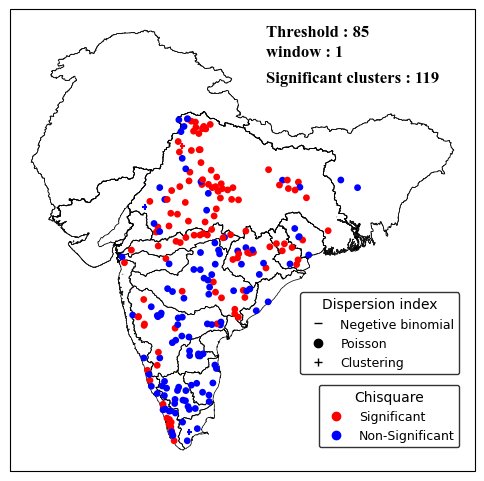

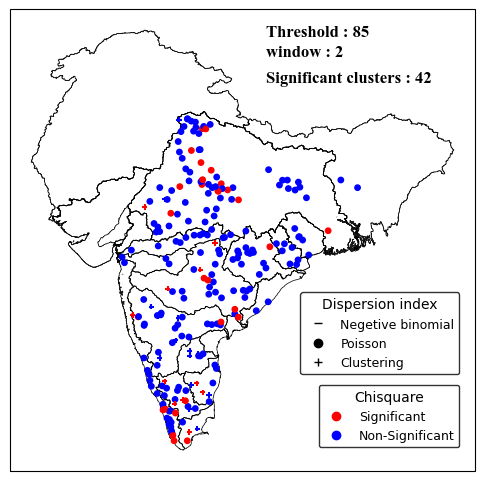

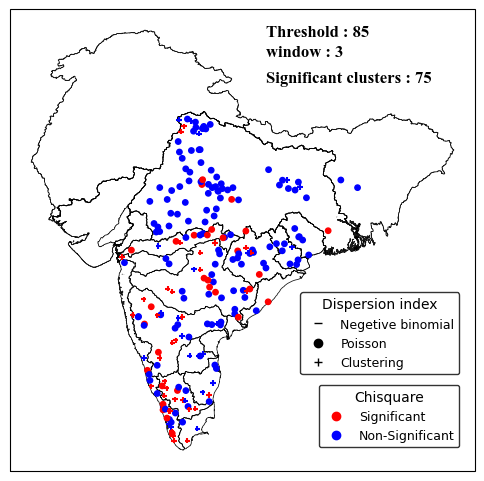

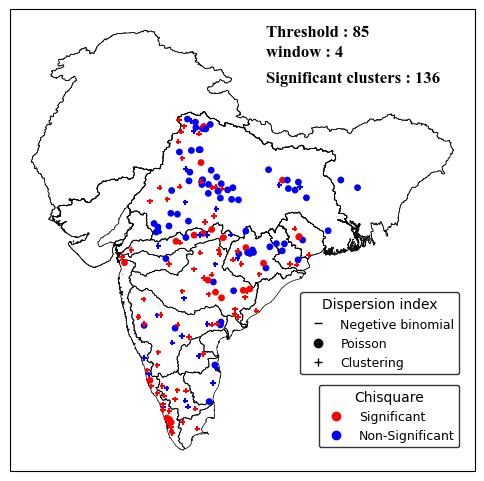

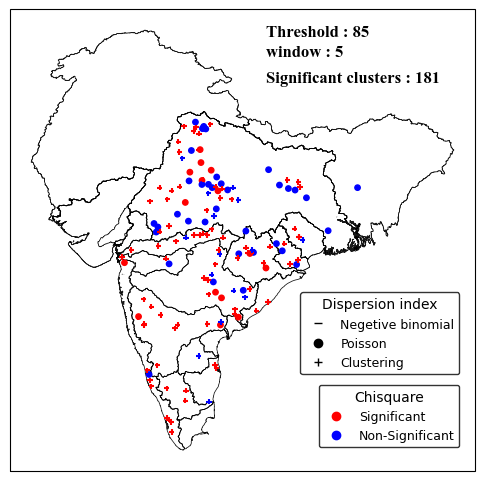

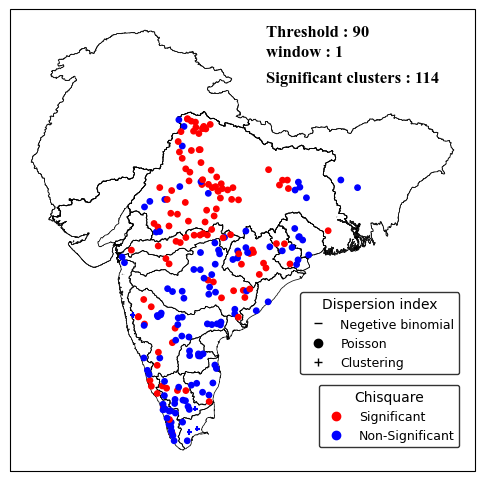

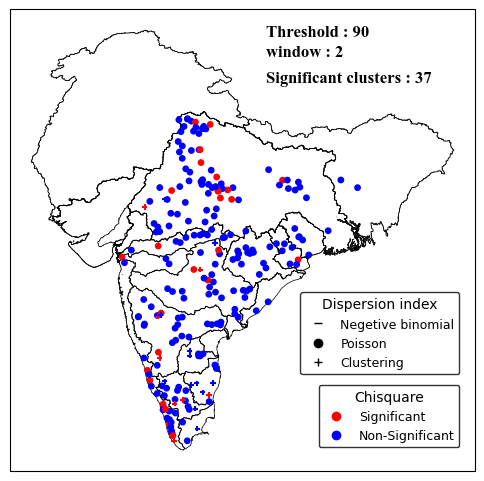

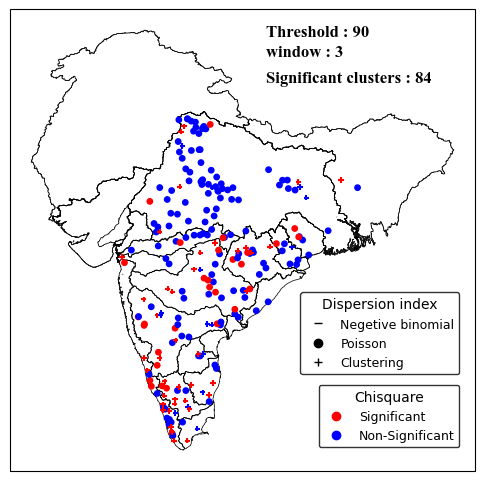

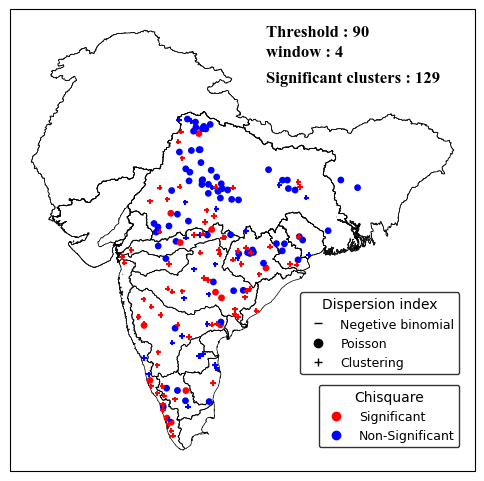

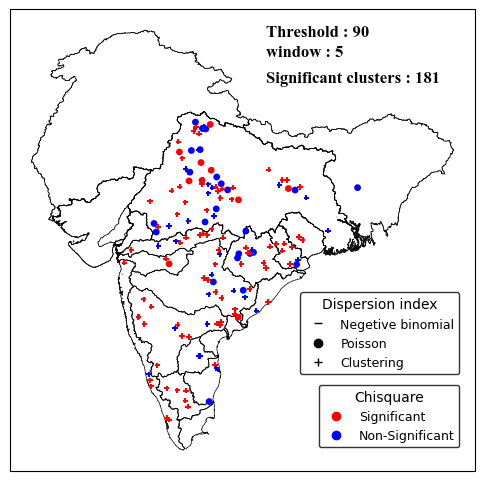

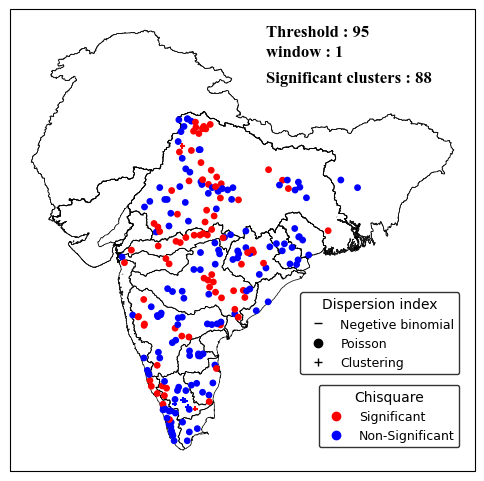

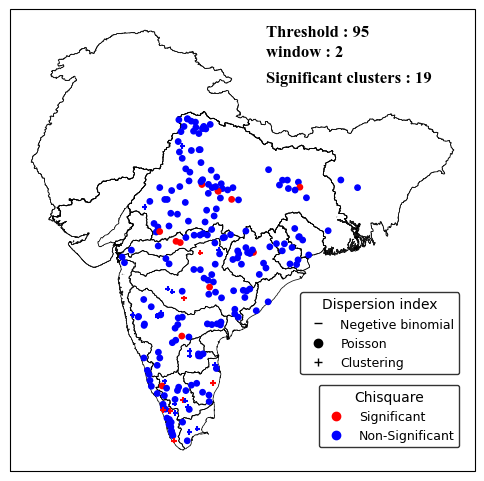

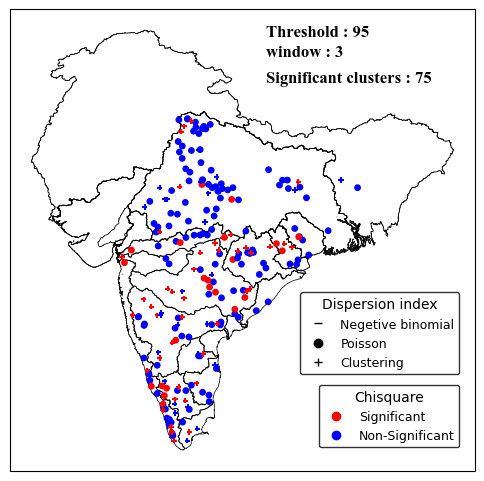

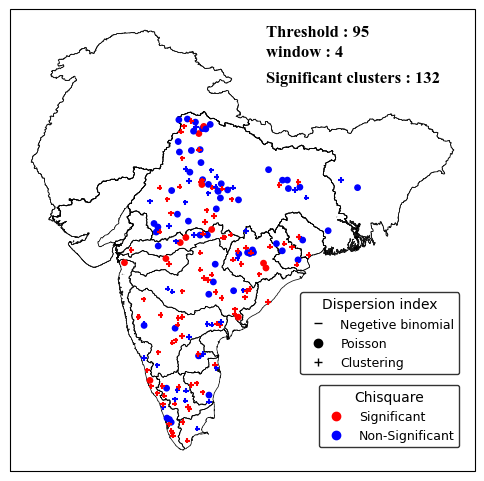

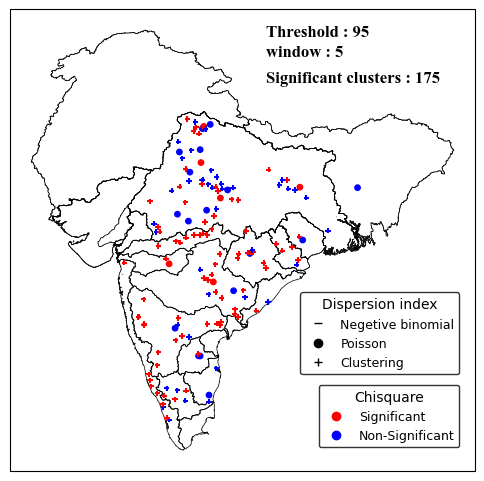

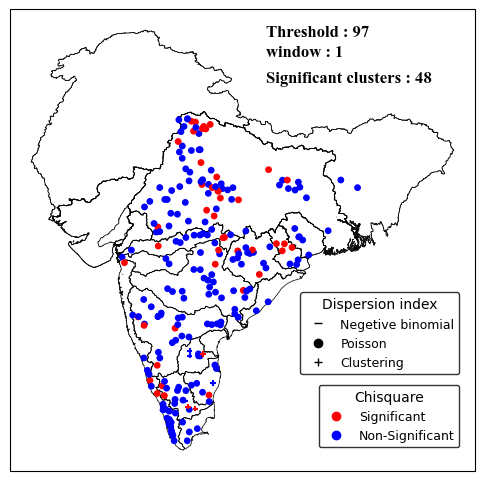

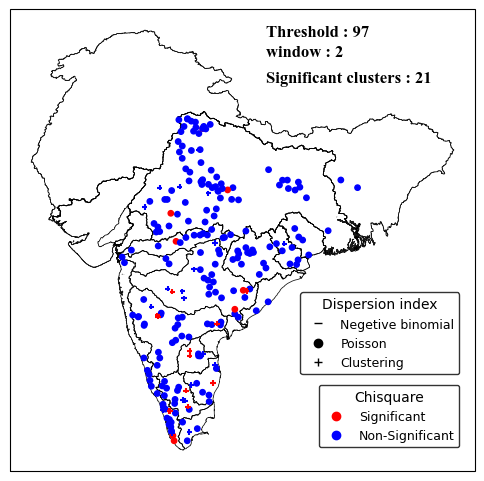

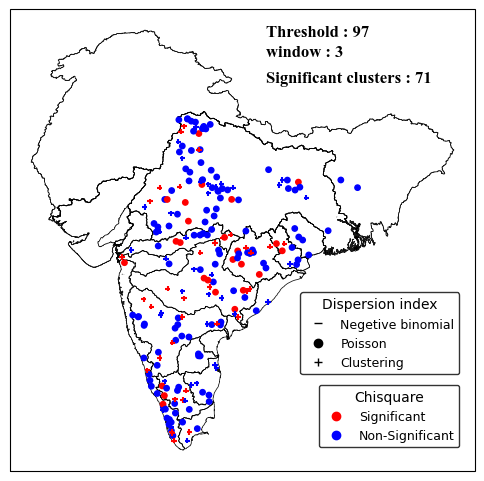

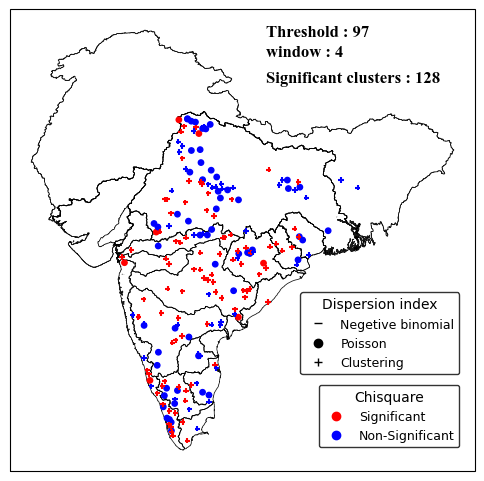

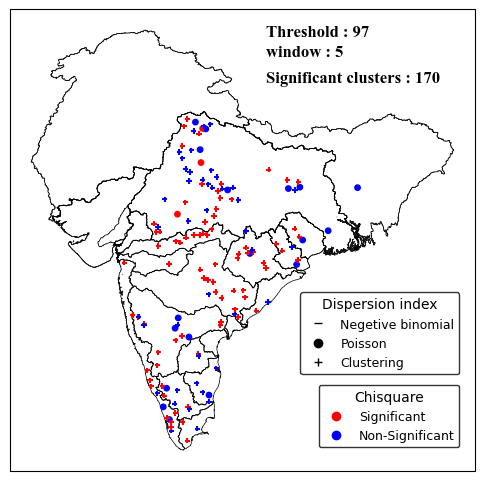

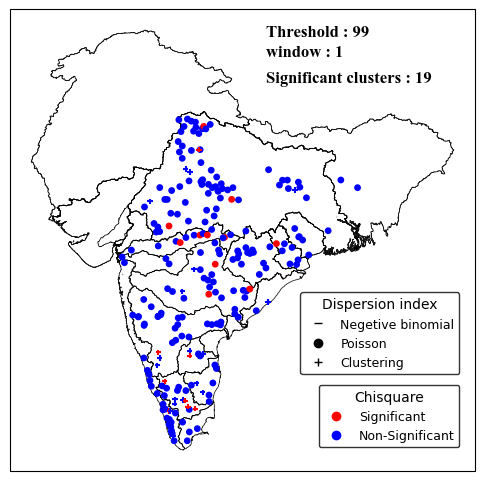

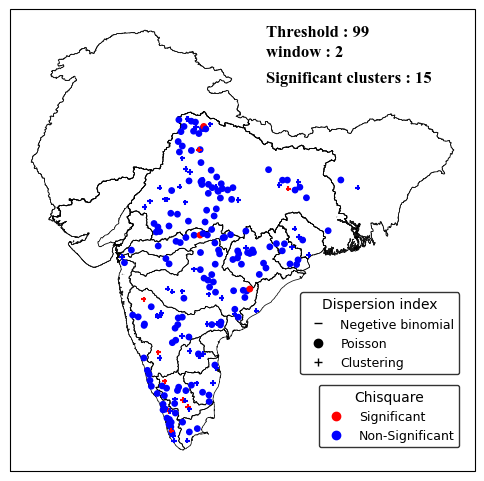

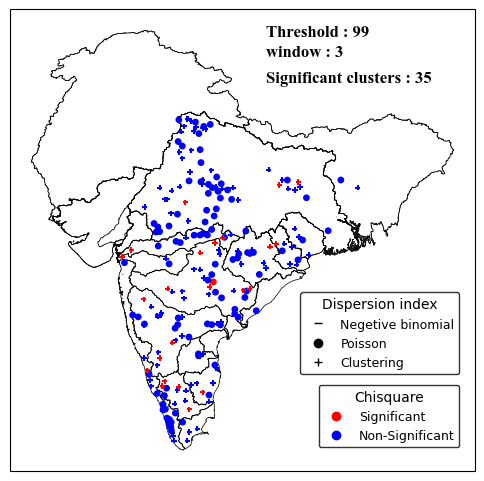

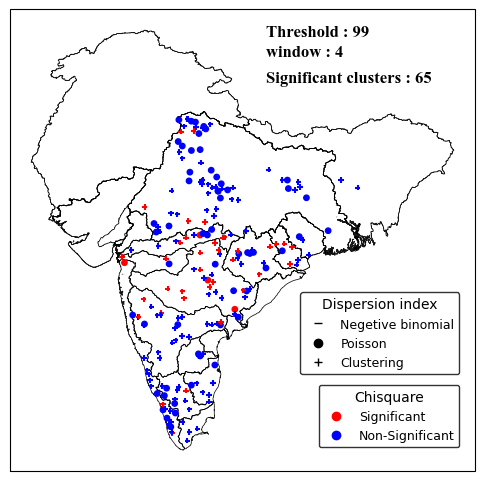

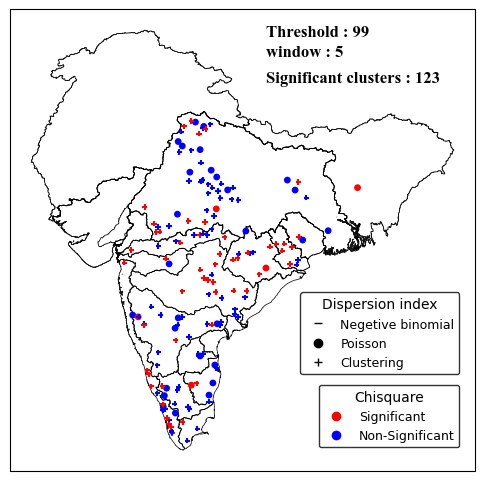

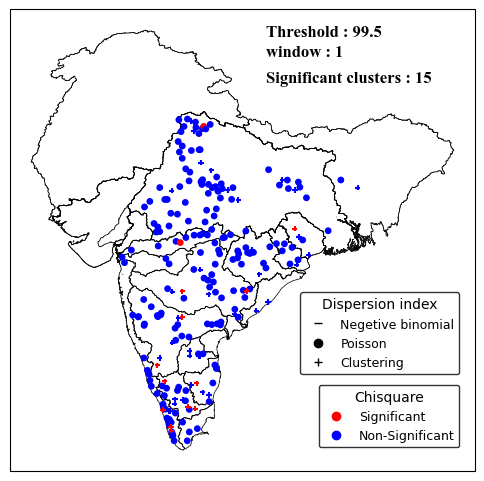

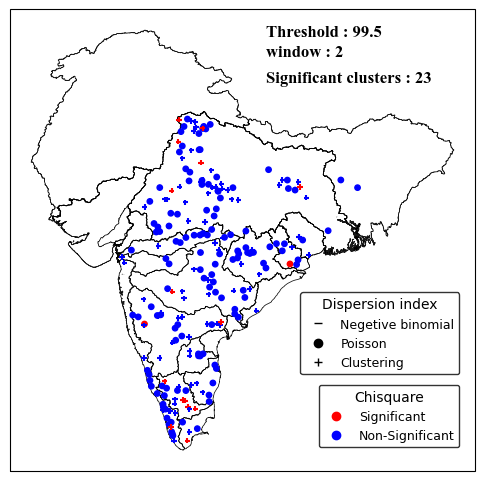

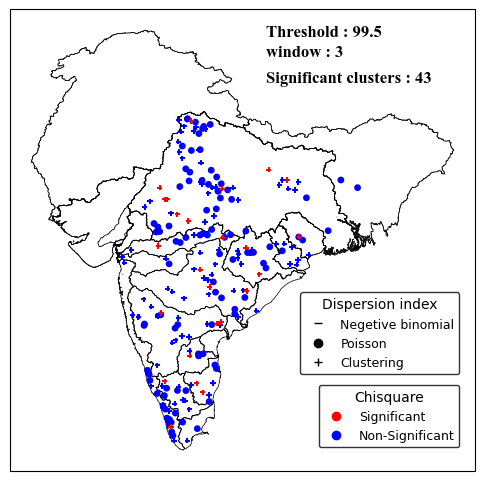

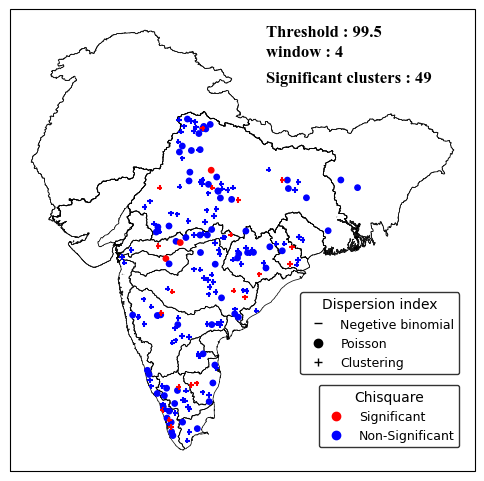

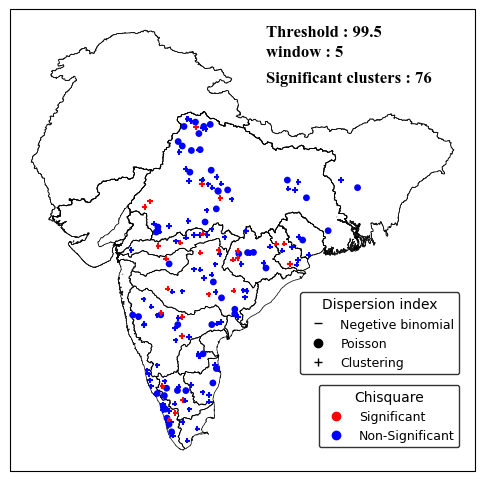

In [ ]:
import matplotlib.lines as mlines
from itertools import product  # For for loop

south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

combinations = list(product(threshold, window_n))
for t,w in zip(*zip(*combinations)):

    fig,ax1 = plt.subplots(1,1,figsize=(6,6),subplot_kw={'projection': ccrs.PlateCarree()})

    south_asia.plot(ax=ax1,color='none',edgecolor='black',linewidth=0.55,alpha=0.9)

    df=result_ds.sel(threshold=t,window=w).to_dataframe()
    df[['Latitude','Longitude']]=gauge_final[['Latitude','Longitude']].to_numpy()
    df['test_color']=df['Chisquare'].apply(lambda x: 'blue' if x >0.05 else 'red')

    bins = [-2,-1.1,1.1,2]
    marker1 = ['_', 'o','+']
    df['Dispersion_marker'] = pd.cut(df['Dispersion'], bins=bins, labels=marker1)


    dispersion_lgnd = []
    for marker_type, label in zip(marker1, ["Negetive binomial", "Poisson","Clustering"]):
        subset = df[df['Dispersion_marker'] == marker_type]
        sc=ax1.scatter(subset['Longitude'],subset['Latitude'],c=subset['test_color'],cmap='viridis',marker=marker_type,s=15)
        dispersion_lgnd.append(mlines.Line2D([], [], color='black', marker=marker_type, linestyle='None', markersize=6, label=label))



    #cbar_ax = fig.add_axes([0.2, 0.17, 0.014, 0.14])
    #cbar = plt.colorbar(sc, cax=cbar_ax, orientation='vertical', fraction=0.03, pad=0.02)
    #cbar.ax.set_xlabel('Mean', fontsize=10, fontname='Times New Roman',weight='bold')
    #cbar.ax.xaxis.set_label_position('top')


    ax1.text(0.55, 0.95, f'Threshold : {t}', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')
    ax1.text(0.55, 0.905, f'window : {w}', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')

    ax1.text(0.55, 0.85, f"Significant clusters : {np.sum(df['Chisquare']<0.05)}", fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')


    test_lgnd = [
        mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=6, label='Significant'),
        mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=6, label='Non-Significant')
    ]

    dispersion_legend=ax1.legend(handles=dispersion_lgnd, title="Dispersion index", title_fontsize=10, fontsize=9, frameon=True, edgecolor='black', bbox_to_anchor=(0.98, 0.4))

    ax1.add_artist(dispersion_legend) # To make multiple legends we have to do like this

    ax1.legend(handles=test_lgnd, title="Chisquare", title_fontsize=10, fontsize=9, frameon=True, edgecolor='black', bbox_to_anchor=(0.98, 0.2))


    plt.savefig(fr'2_Analysis\2_Temperol clustering\Outputs\Poisson test\{t}_{w}.png', bbox_inches='tight',dpi=1000)

# 2. Clustering analysis (yearly)


In [ ]:
gauge_final=gauge_final[["GaugeID","Station","Latitude","Longitude"]]


# 1 Define scan statistics parameters

m = 3  
step = 1  
window_starts = pd.date_range(start="1970", end=pd.to_datetime('2022')-pd.DateOffset(years=m), freq=pd.DateOffset(years=step))
window_starts
flood_rich=pd.DataFrame(columns=window_starts,index=gauge_final["GaugeID"].values)


for g,stn in enumerate(gauge_final['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) 

    #data1=data1[(data1.index.year<2015)]
    #data2=data1[data1.index.month.isin([5,6,7,8,9])]


    #Extracting flood event 
    thr=np.percentile(data1['Streamflow (cumecs)'],99)
    POT = data1[data1['Streamflow (cumecs)'] > thr]
    POT["Date"] = POT.index

    # Independent criteria  #Minimum 20 days gap
    IC=pd.Timedelta(days=30)
    POT=POT[POT["Date"].diff().fillna(pd.Timedelta(days=50)) > IC]


    data1["Exceedance"] = 0  # Initialize with 0
    data1.loc[POT.index, "Exceedance"] = 1
    

    clip_st = window_starts[window_starts.get_indexer([data1.index.min()], method="bfill")[0]]          
    clip_en = window_starts[window_starts.get_indexer([data1.index.max()], method="ffill")[-1]]
    data1=data1.loc[clip_st:clip_en]



    # 3️⃣ Compute scan statistic: max number of exceedances in any window
    scan_counts = []
    window_data = pd.date_range(start=data1.index.min(), end=data1.index.max() - pd.DateOffset(years=m), freq=pd.DateOffset(years=step))


    for start in window_data:
        end = start + pd.DateOffset(years=m)
        count = data1.loc[start:end, "Exceedance"].sum()  # Count exceedances in window
        scan_counts.append(count)
        flood_rich.loc[stn,start] = count


    max_Sm = max(scan_counts)
    min_Sm = min(scan_counts)

    # 4️⃣ Compute P(Sm ≥ k) under null hypothesis (constant probability p0)
    lambda_window = data1["Exceedance"].sum() / ((data1.index.max().year - data1.index.min().year) or 1)  # Avg. floods per year
    lambda_m = lambda_window * m  # Expected floods in window
    p_value = 1 - stats.poisson.cdf(max_Sm - 1, lambda_m)  # P(X ≥ max_Sm)

    gauge_final.loc[g,'p_value']=p_value
    gauge_final.loc[g,'max_count']=max_Sm

#out1=pd.DataFrame.from_dict(rst_detaield, orient="index", columns=[f"{i}" for i in range(len(window_starts))])
#out2=pd.DataFrame.from_dict(rst, orient="index", columns=['p_value','max_sum'])
flood_rich.to_csv(r"2_Analysis\2_Temperol clustering\Outputs\clustering.csv")


C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_28156\1454798048.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  POT["Date"] = POT.index
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_28156\1454798048.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  POT["Date"] = POT.index
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_28156\1454798048.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

### Repairing Works

In [4]:
gauge_final=gauge_final[["GaugeID","Station","Latitude","Longitude"]]


# 1 Define scan statistics parameters

m = 3  
step = 1  
window_starts = pd.date_range(start="1970", end=pd.to_datetime('2022')-pd.DateOffset(years=m), freq=pd.DateOffset(years=step))
window_starts
flood_rich=pd.DataFrame(columns=window_starts,index=gauge_final["GaugeID"].values)


stn=gauge_final['GaugeID'].values[4]

data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) 

data1


,Streamflow (cumecs)
Date,
1965-06-01,35.90
1965-06-02,12.20
1965-06-03,30.10
1965-06-04,33.20
1965-06-05,35.20
...,...
2019-01-30,0.95
2019-01-31,0.83
2019-02-01,0.69


In [ ]:

#Extracting flood event 
thr=np.percentile(data1['Streamflow (cumecs)'],99)
POT = data1[data1['Streamflow (cumecs)'] > thr]
POT["Date"] = POT.index

# Independent criteria  #Minimum 20 days gap
IC=pd.Timedelta(days=30)
POT=POT[POT["Date"].diff().fillna(pd.Timedelta(days=50)) > IC]


data1["Exceedance"] = 0  # Initialize with 0
data1.loc[POT.index, "Exceedance"] = 1


clip_st = window_starts[window_starts.get_indexer([data1.index.min()], method="bfill")[0]]          
clip_en = window_starts[window_starts.get_indexer([data1.index.max()], method="ffill")[-1]]
data1=data1.loc[clip_st:clip_en]



# 3️⃣ Compute scan statistic: max number of exceedances in any window
scan_counts = []
window_data = pd.date_range(start=data1.index.min(), end=data1.index.max() - pd.DateOffset(years=m), freq=pd.DateOffset(years=step))


for start in window_data:
    end = start + pd.DateOffset(years=m)
    count = data1.loc[start:end, "Exceedance"].sum()  # Count exceedances in window
    scan_counts.append(count)
    flood_rich.loc[stn,start] = count


max_Sm = max(scan_counts)
min_Sm = min(scan_counts)

# 4️⃣ Compute P(Sm ≥ k) under null hypothesis (constant probability p0)
lambda_window = data1["Exceedance"].sum() / ((data1.index.max().year - data1.index.min().year) or 1)  # Avg. floods per year
lambda_m = lambda_window * m  # Expected floods in window
p_value = 1 - stats.poisson.cdf(max_Sm - 1, lambda_m)  # P(X ≥ max_Sm)

gauge_final.loc[g,'p_value']=p_value
gauge_final.loc[g,'max_count']=max_Sm

#out1=pd.DataFrame.from_dict(rst_detaield, orient="index", columns=[f"{i}" for i in range(len(window_starts))])
#out2=pd.DataFrame.from_dict(rst, orient="index", columns=['p_value','max_sum'])
flood_rich.to_csv(r"2_Analysis\2_Temperol clustering\Outputs\clustering.csv")


# 2 PLOTs

### 2.1 Map

In [14]:
data=gauge_final[gauge_final['p_value']<0.05]
Station_Map(data,'ss')


#plt.savefig(fr'2_Analysis\2_Temperol clustering\Outputs\{condition}', bbox_inches='tight',dpi=1000)

NameError: name 'Station_Map' is not defined

## 2.1 Timeseries

Text(0.5, 1.0, 'Kodumudi')

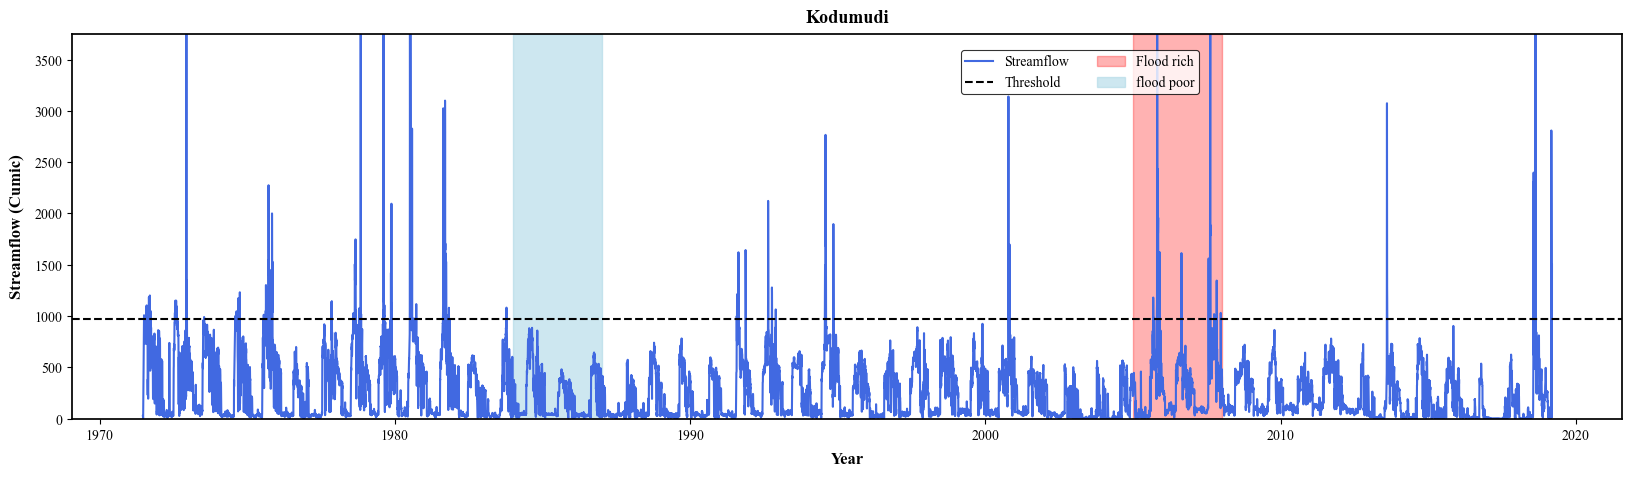

In [13]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.serif"] = "Times New Roman"

gauge=gauge_final[gauge_final['p_value']<0.05] 
gauge.reset_index(drop=True,inplace=True)
g=12

stn=gauge['GaugeID'].values[g]

data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) 


# Create figure and axis
fig, ax = plt.subplots(figsize=(20, 5))


[x.set_linewidth(1.25) for x in ax.spines.values()]

# Plot time series
ax.plot(data1.index, data1['Streamflow (cumecs)'], linestyle="-", color="royalblue", label="Streamflow")
#ax.bar(data1.index, data1['Streamflow (cumecs)'], label="Streamflow", width=2)  


# Add horizontal threshold line
thr=np.percentile(data1['Streamflow (cumecs)'],98)

ax.axhline(y=thr, color="black", linestyle="--", label=f"Threshold")

# flood rich
strt=flood_rich.loc[stn].astype(float).idxmax()
end=strt+pd.DateOffset(years=m)
ax.axvspan(strt, end, color="red", alpha=0.3, label="Flood rich")

# flood Poor
strt2=flood_rich.loc[stn].astype(float).idxmin()
end2=strt2+pd.DateOffset(years=m)
ax.axvspan(strt2, end2, color="lightblue", alpha=0.6, label="flood poor")



# Formatting
ax.set_ylim(0,np.percentile(data1['Streamflow (cumecs)'],99.9))


ax.set_xlabel('Year',fontsize=12,labelpad=7,weight='bold')
ax.set_ylabel("Streamflow (Cumic)",fontsize=12,labelpad=7,weight='bold')



lgnd=plt.legend(loc='center', ncol=2,fontsize=10, bbox_to_anchor=(0.65, 0.9),frameon=True, borderpad=0.32, edgecolor='black')
frame = lgnd.get_frame()
frame.set_linewidth(0.8)


station=gauge.loc[g,'Station']
ax.set_title(f"{station}",fontsize=13,pad=8,fontname='Times New Roman',weight='bold')

# Show plot
#plt.savefig(fr'2_Analysis\2_Temperol clustering\Outputs\Flood_rich\{station}.jpeg', bbox_inches='tight',dpi=1000)



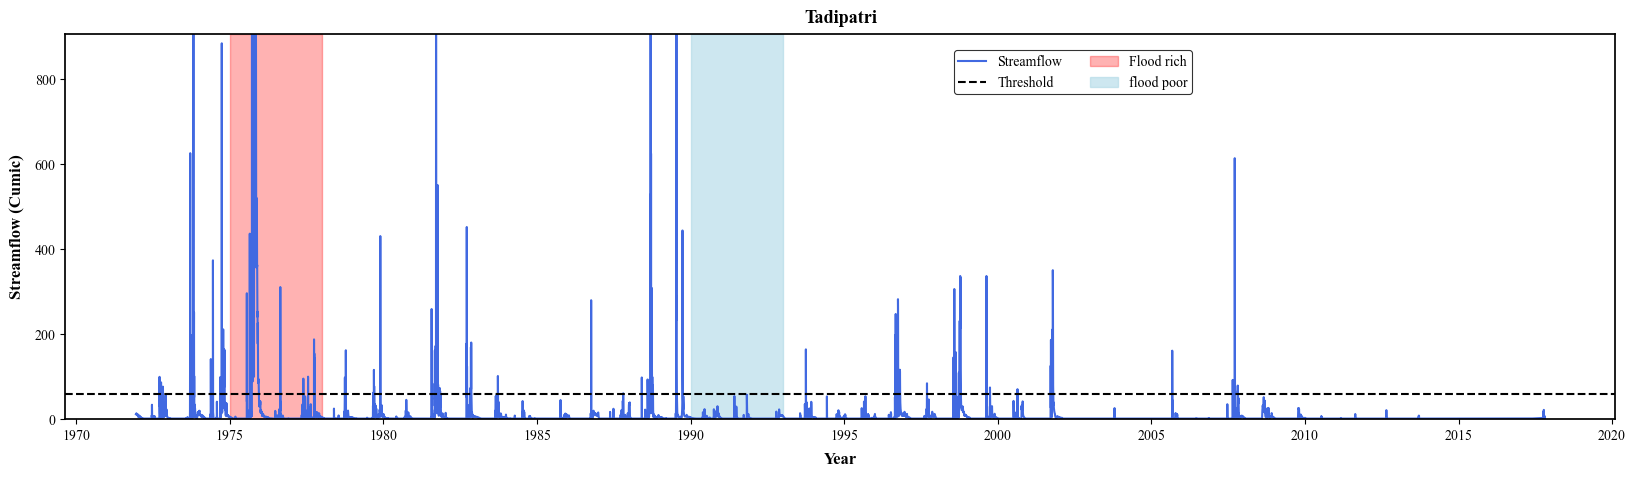

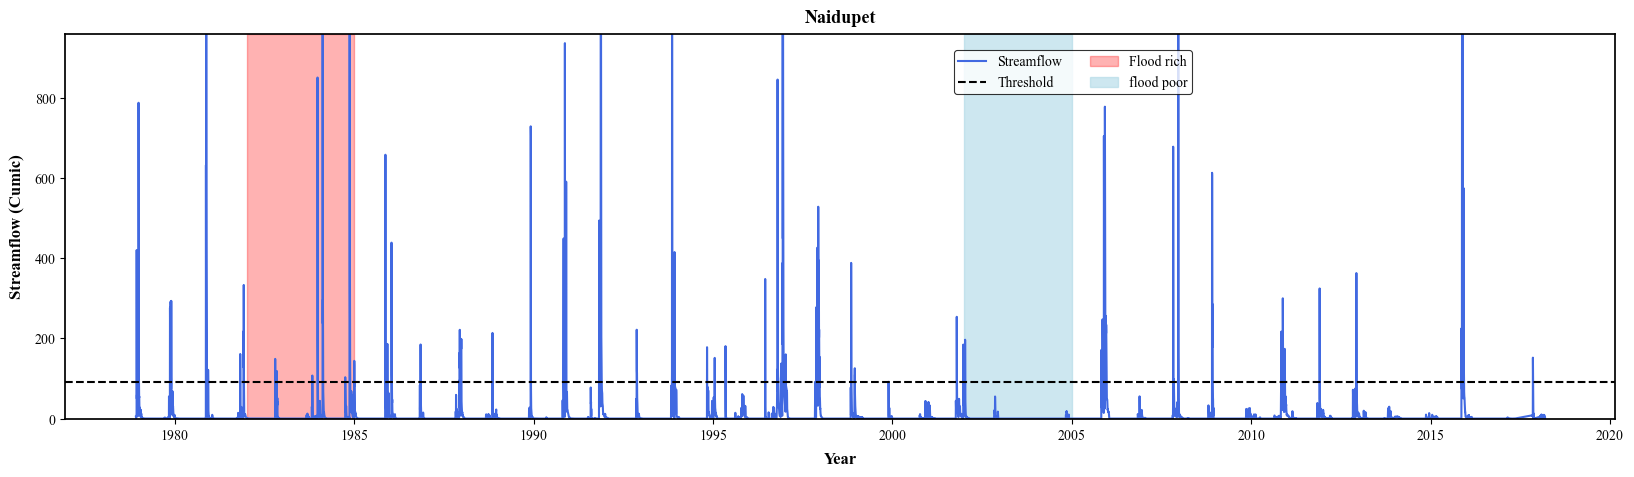

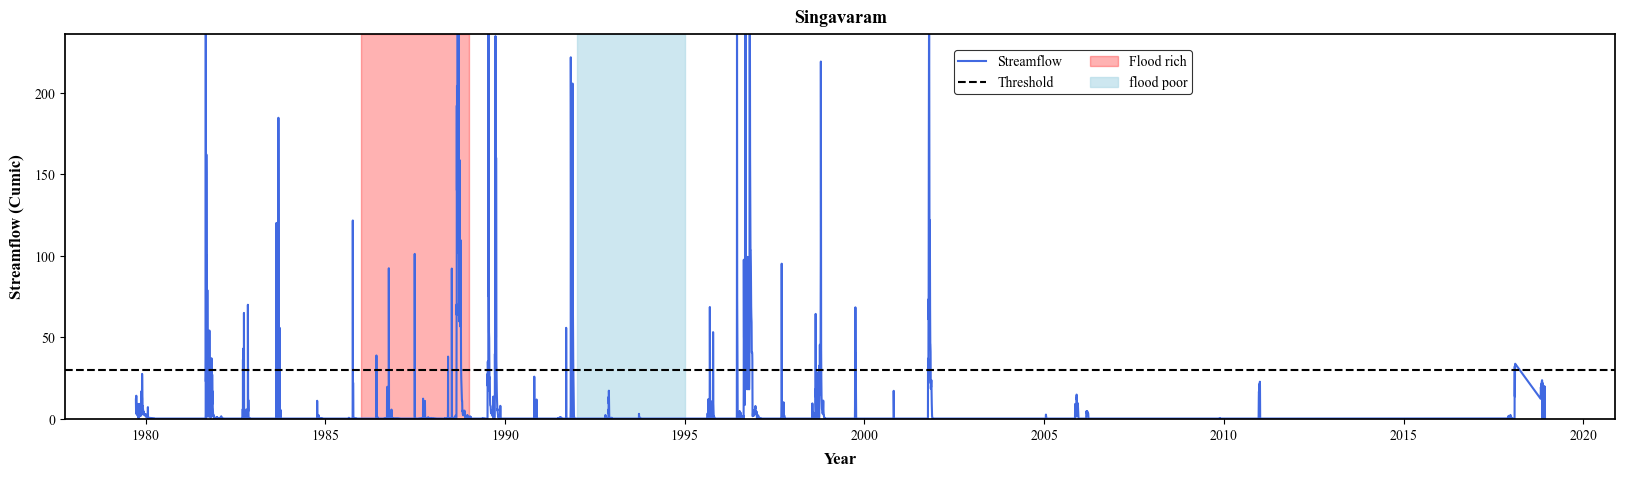

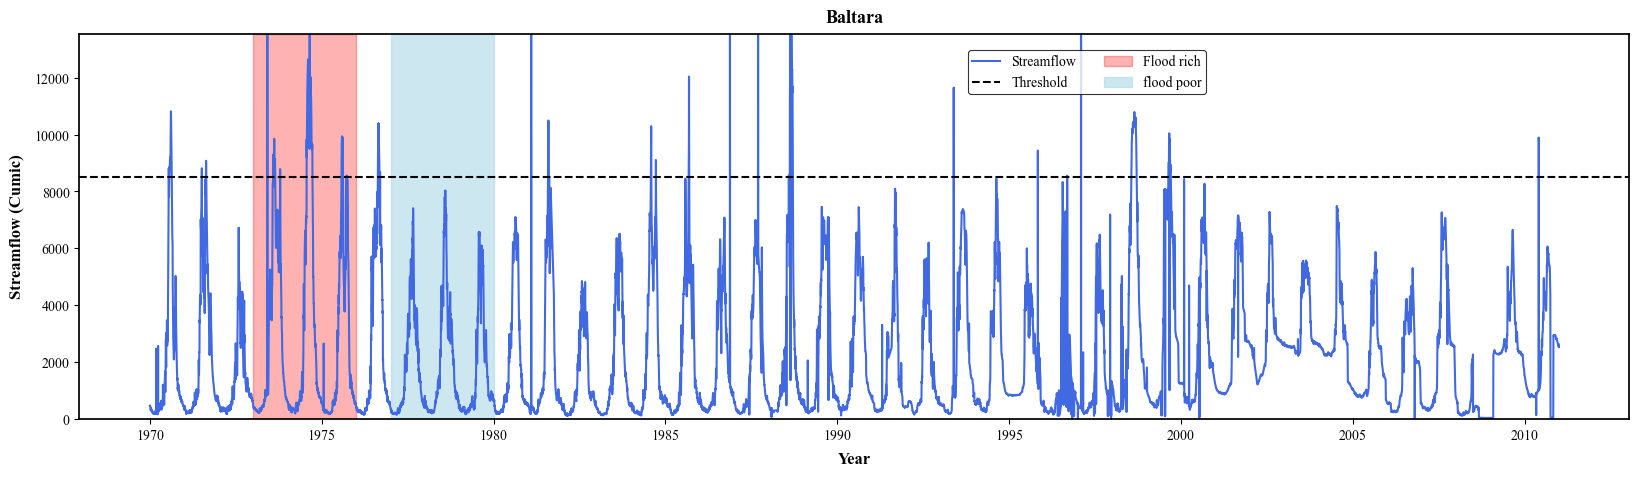

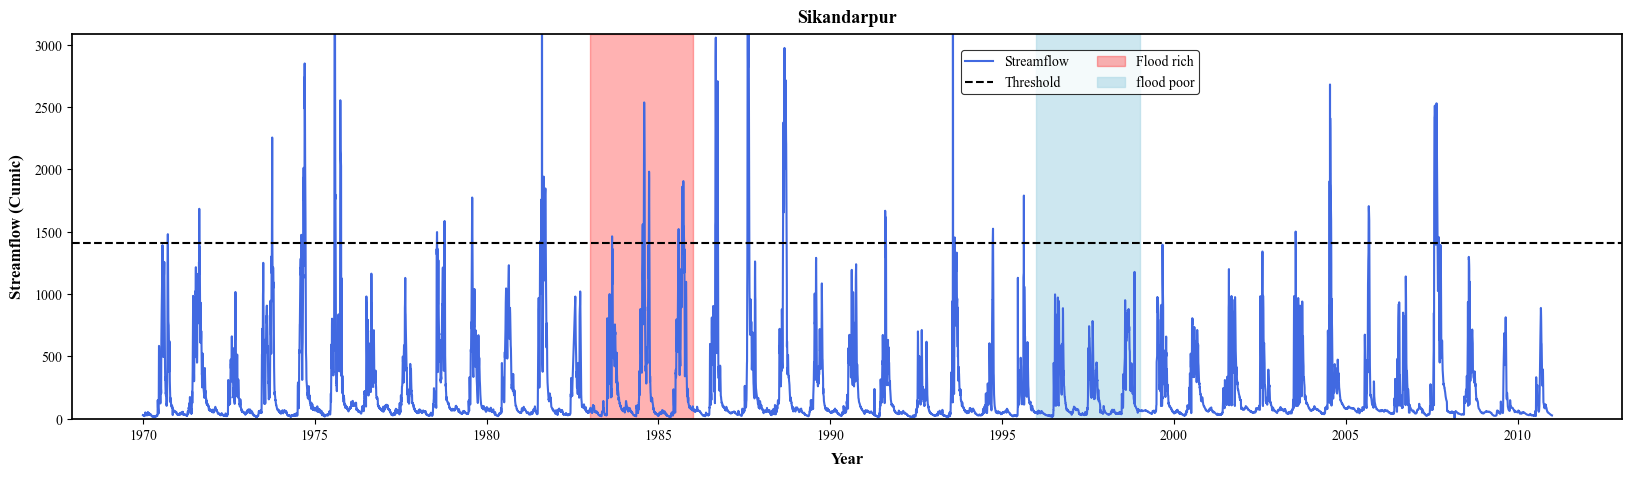

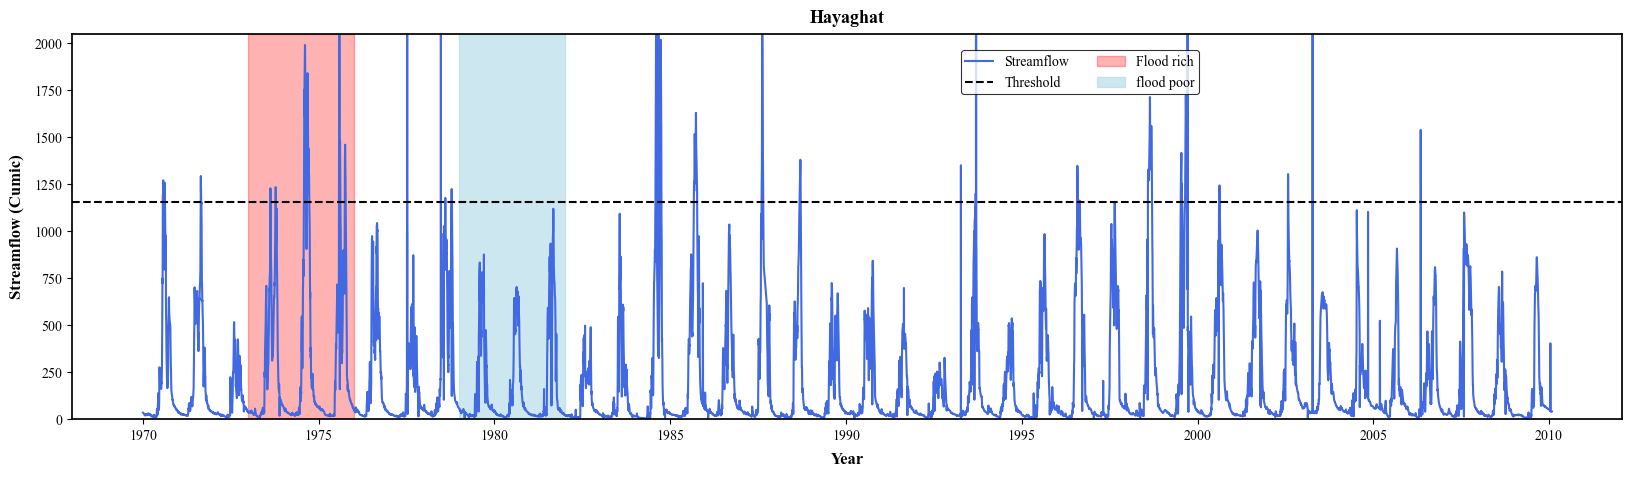

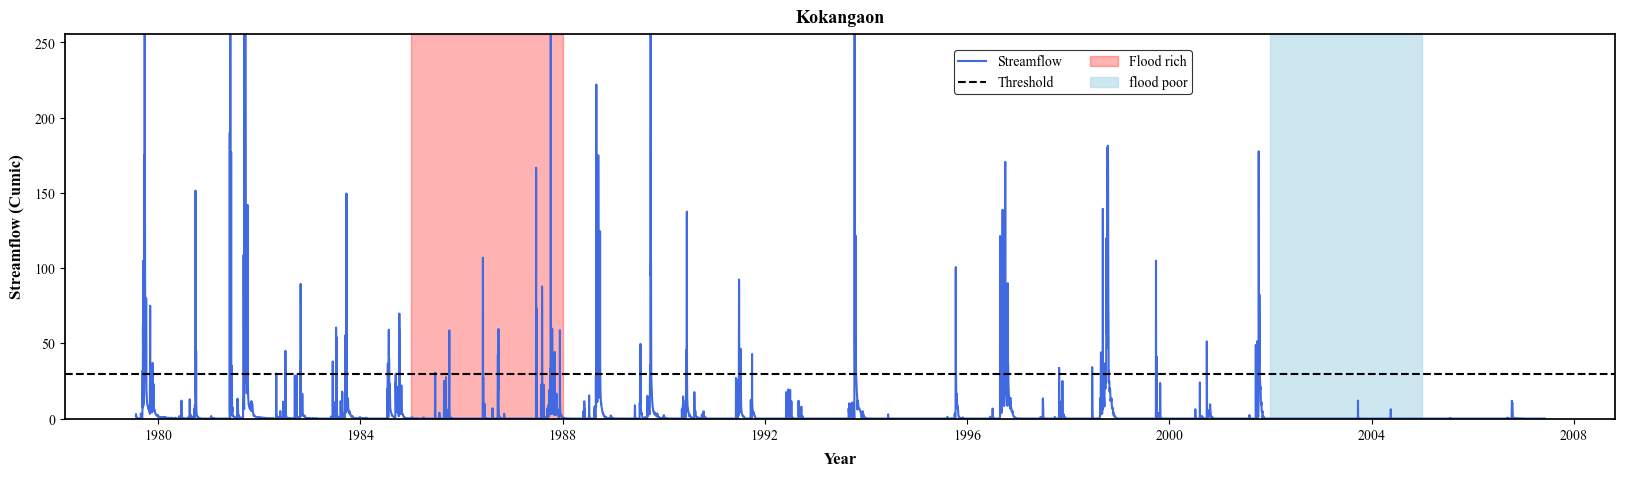

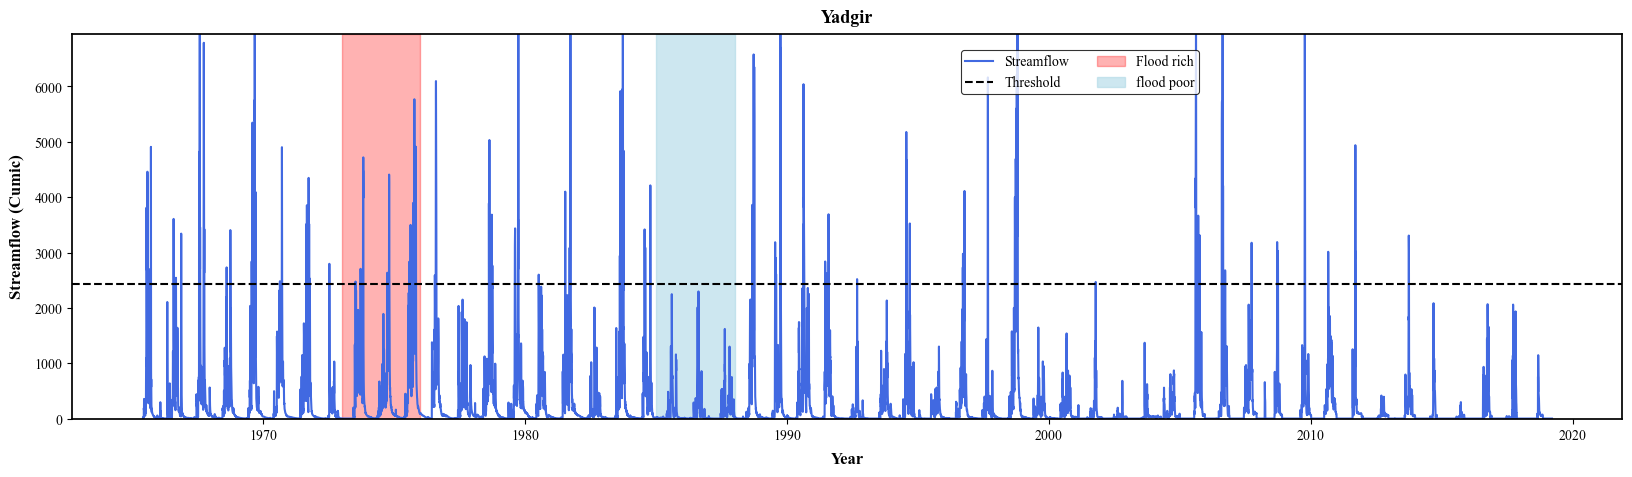

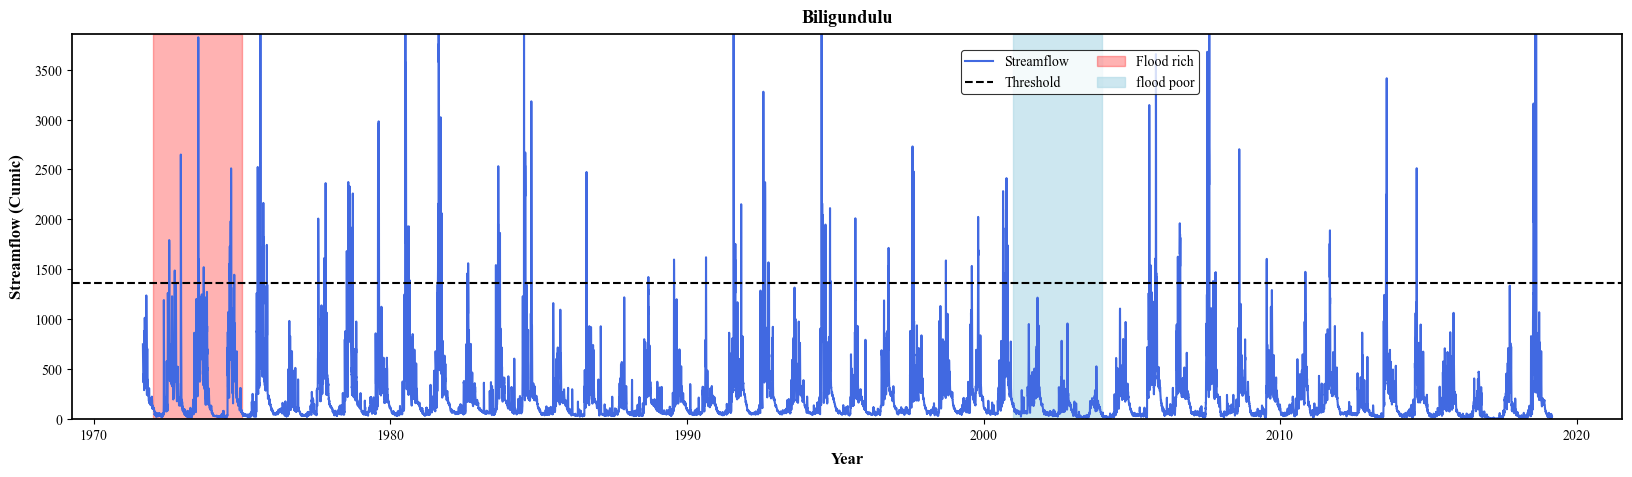

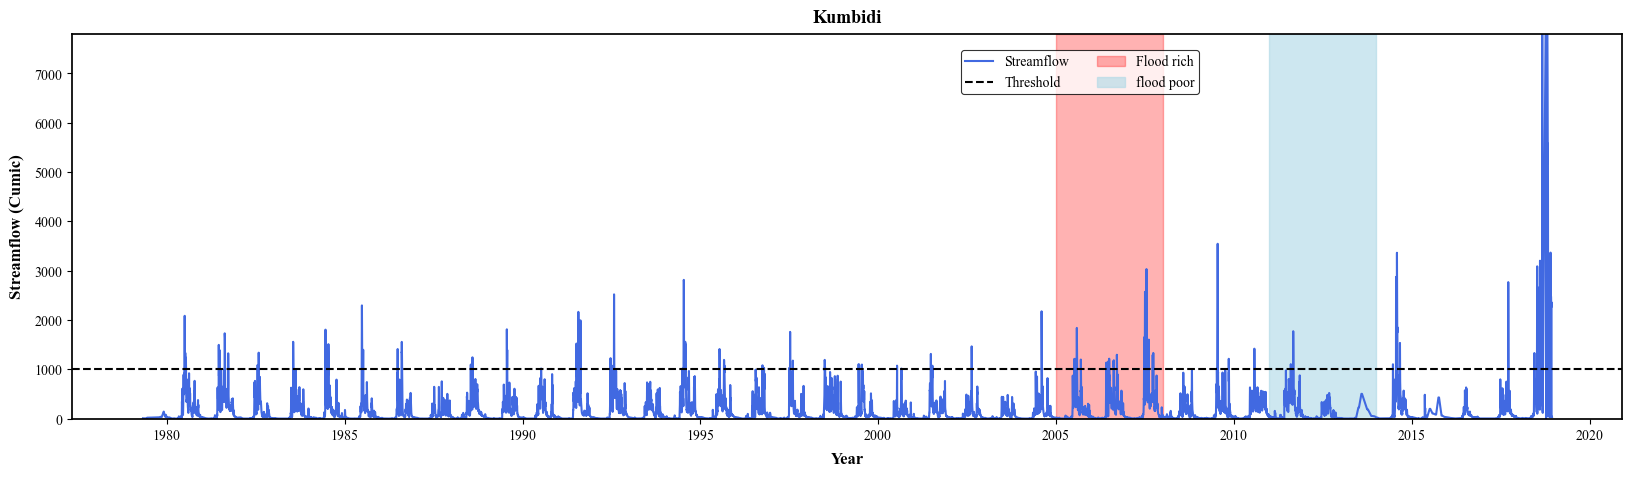

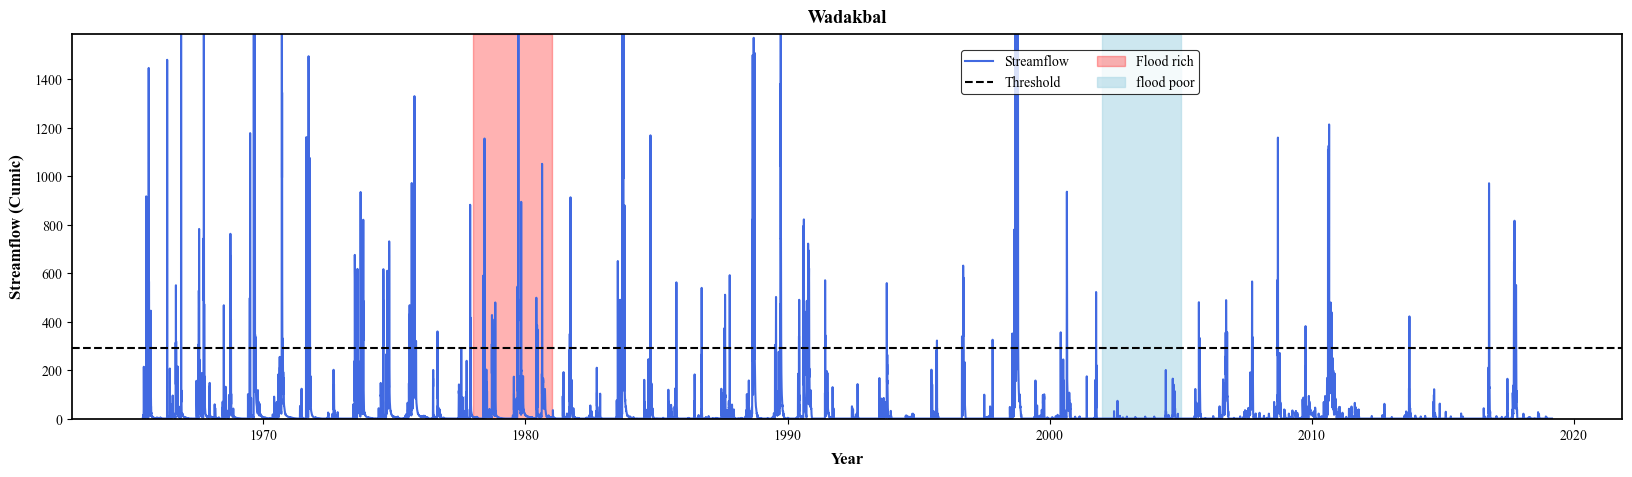

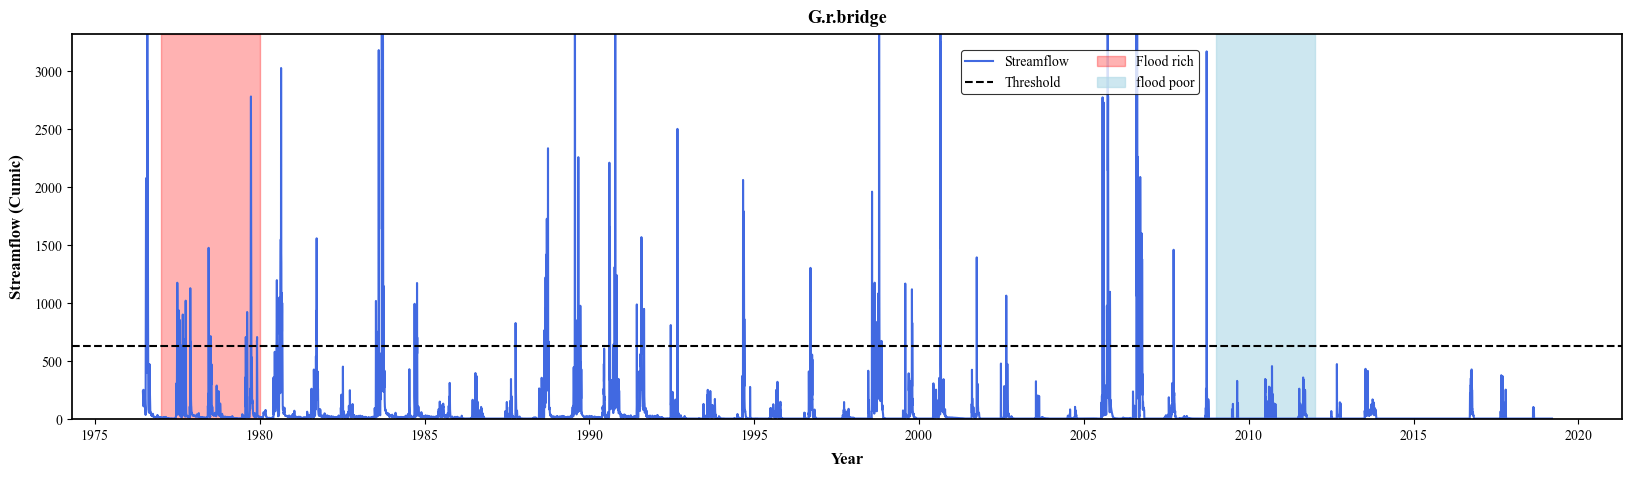

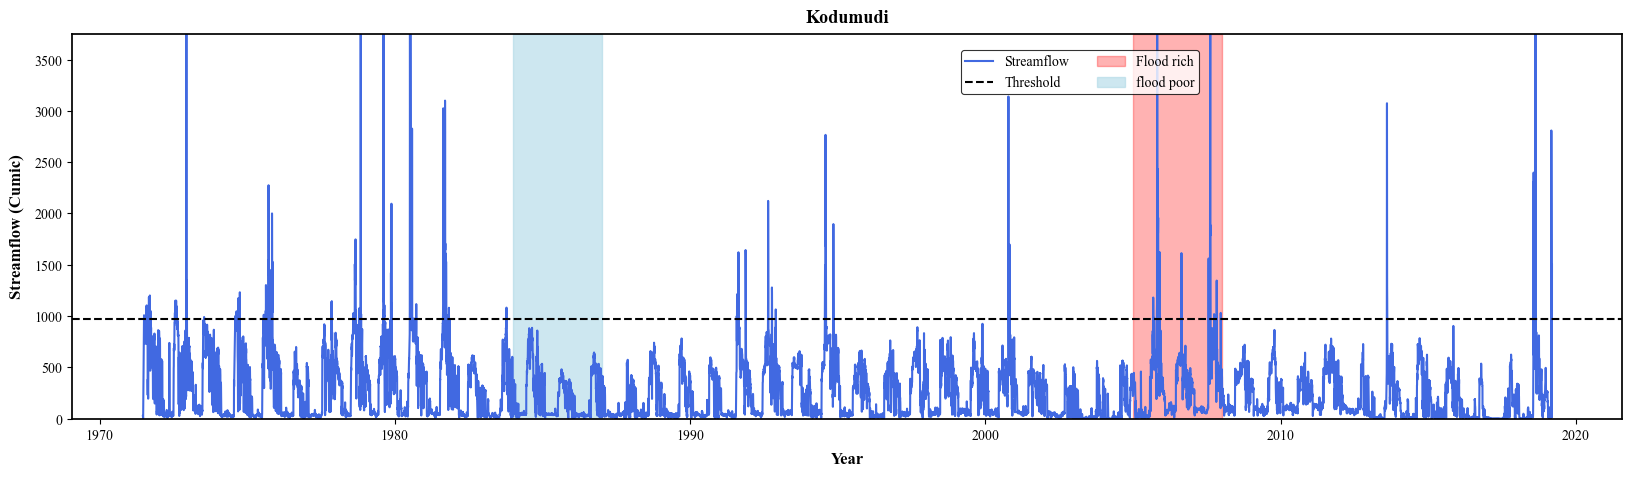

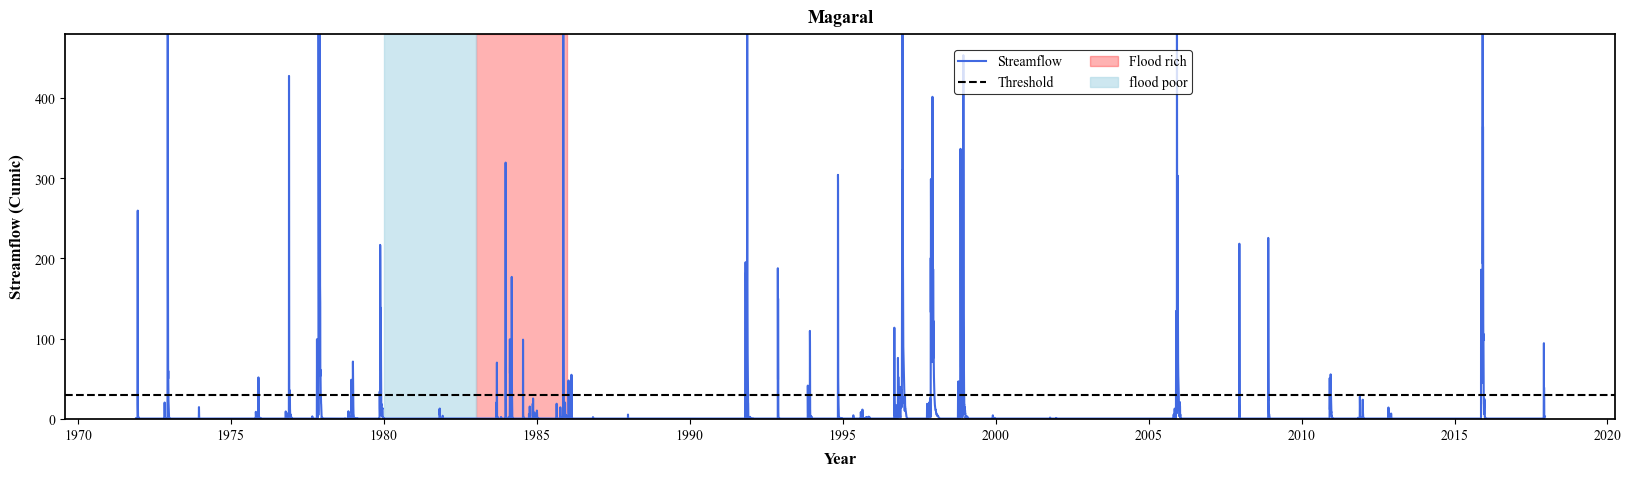

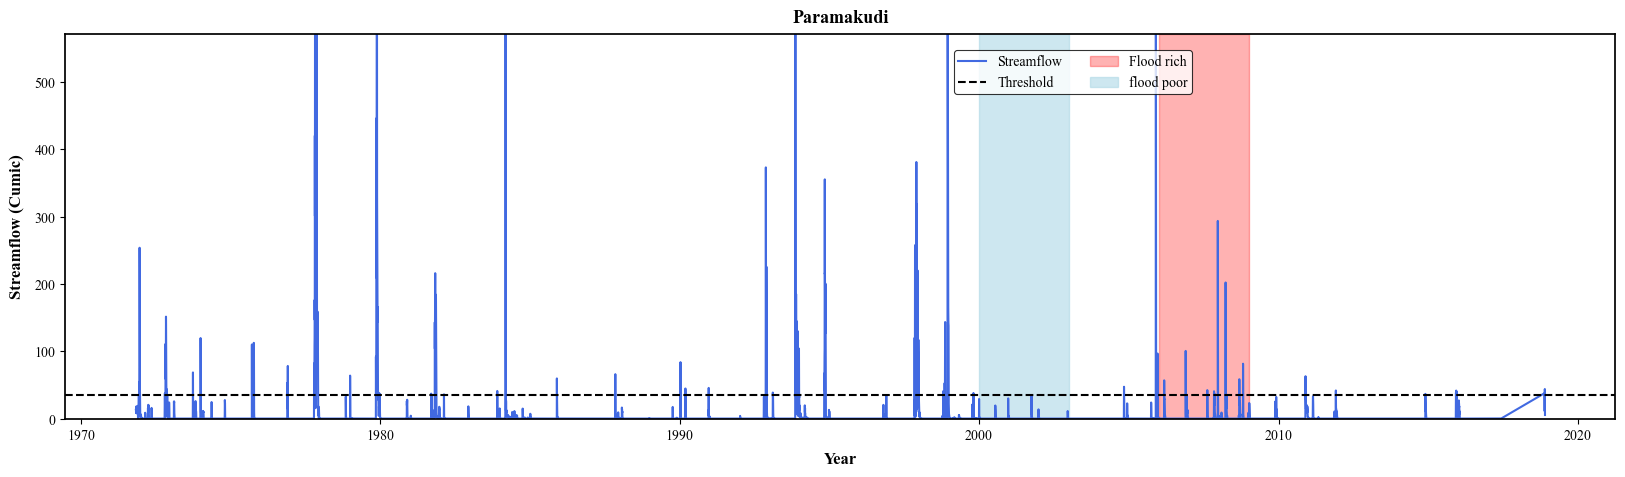

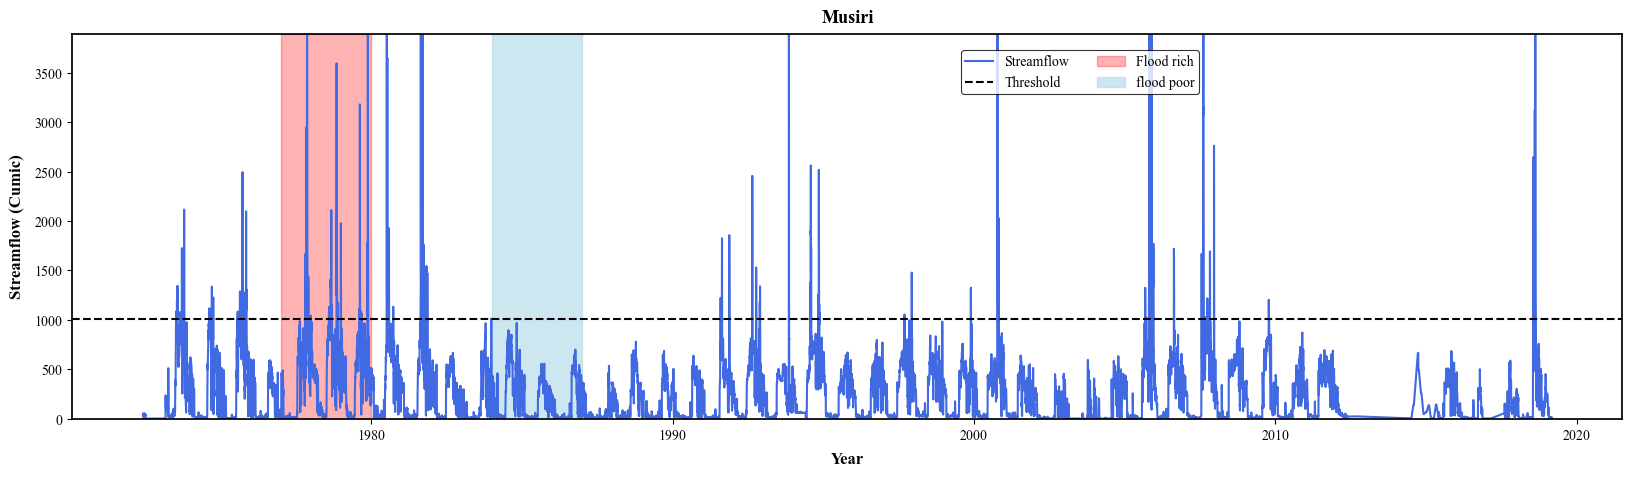

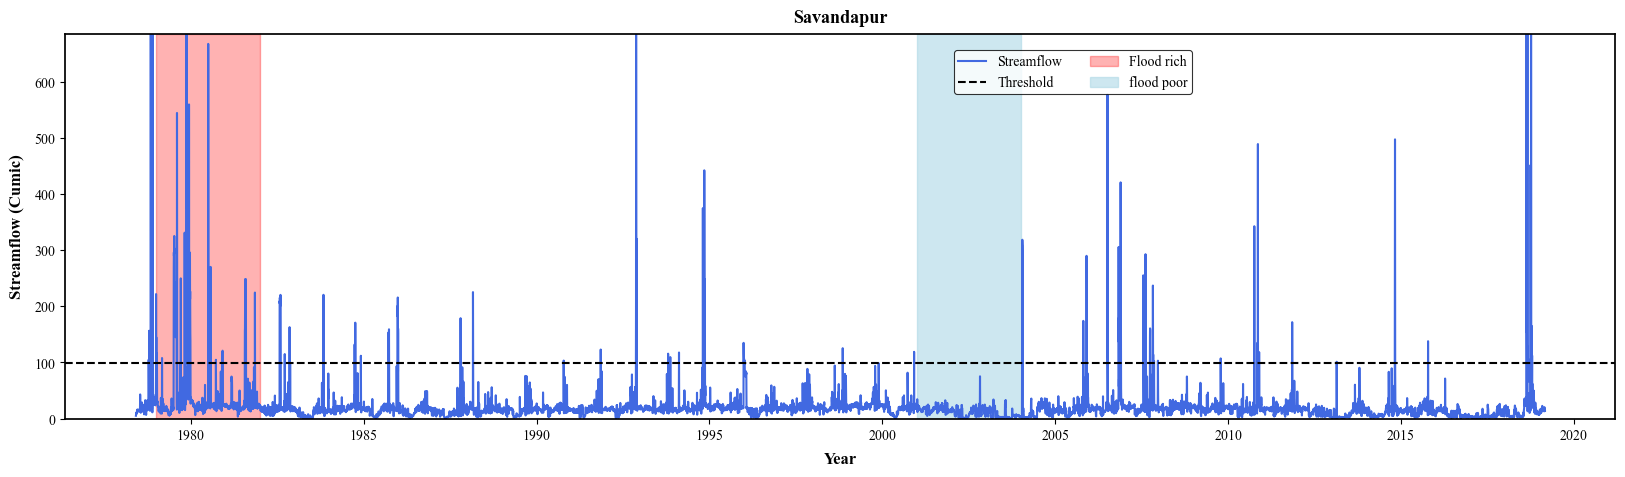

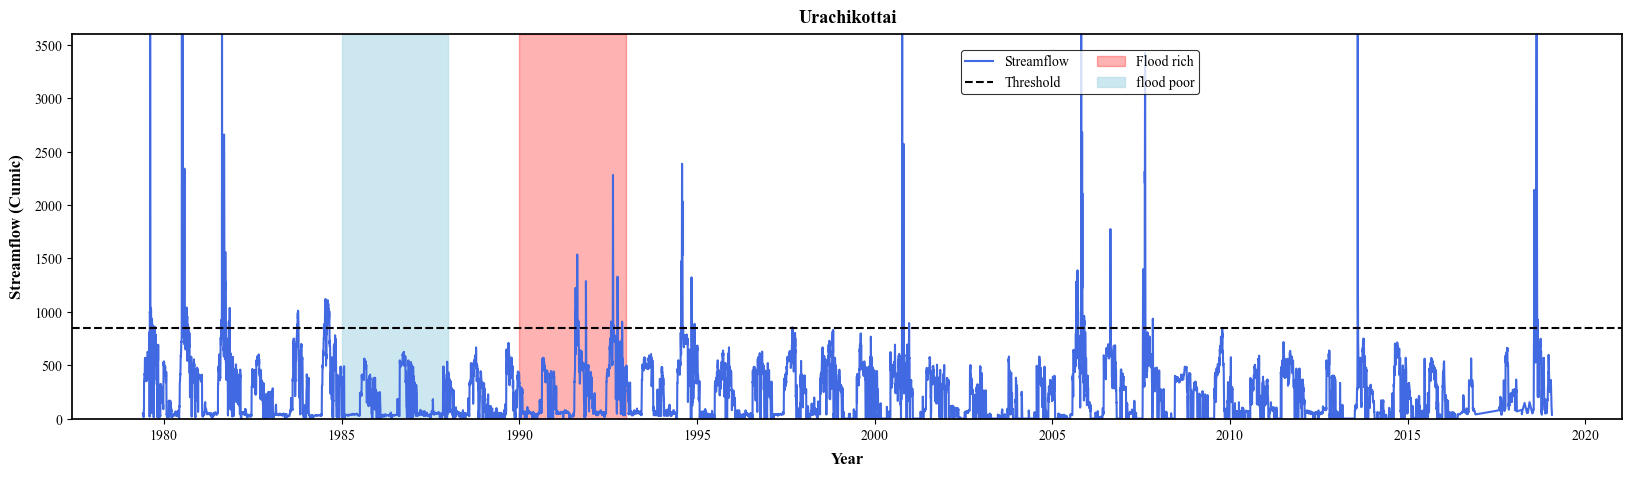

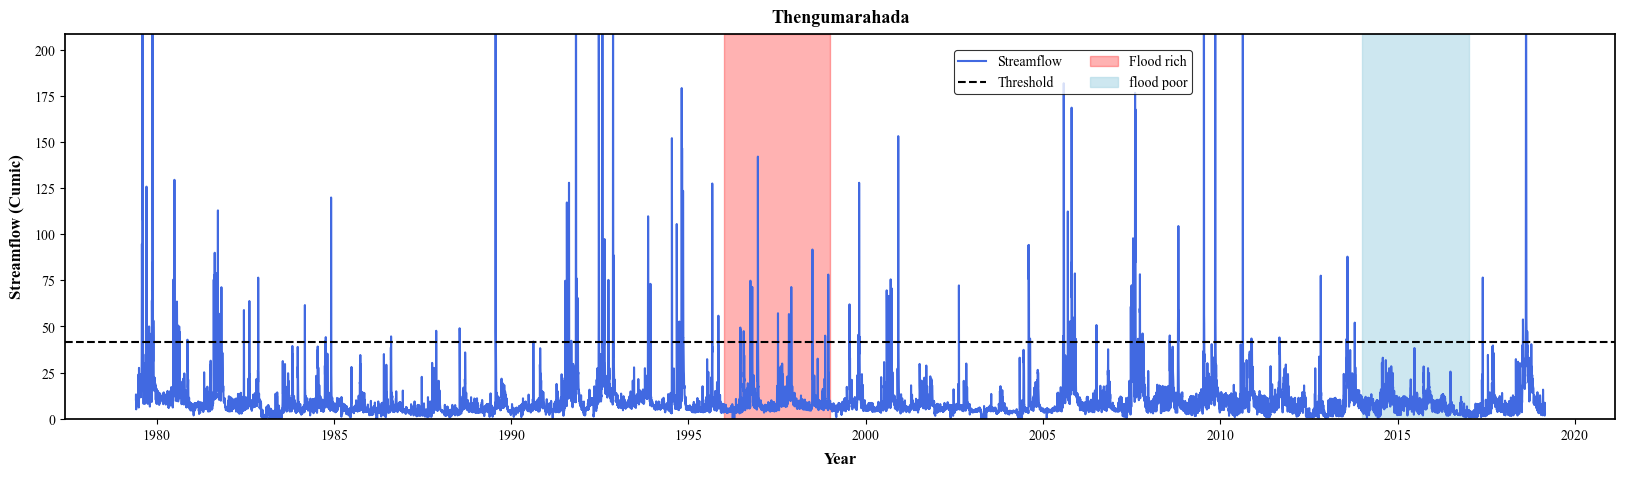

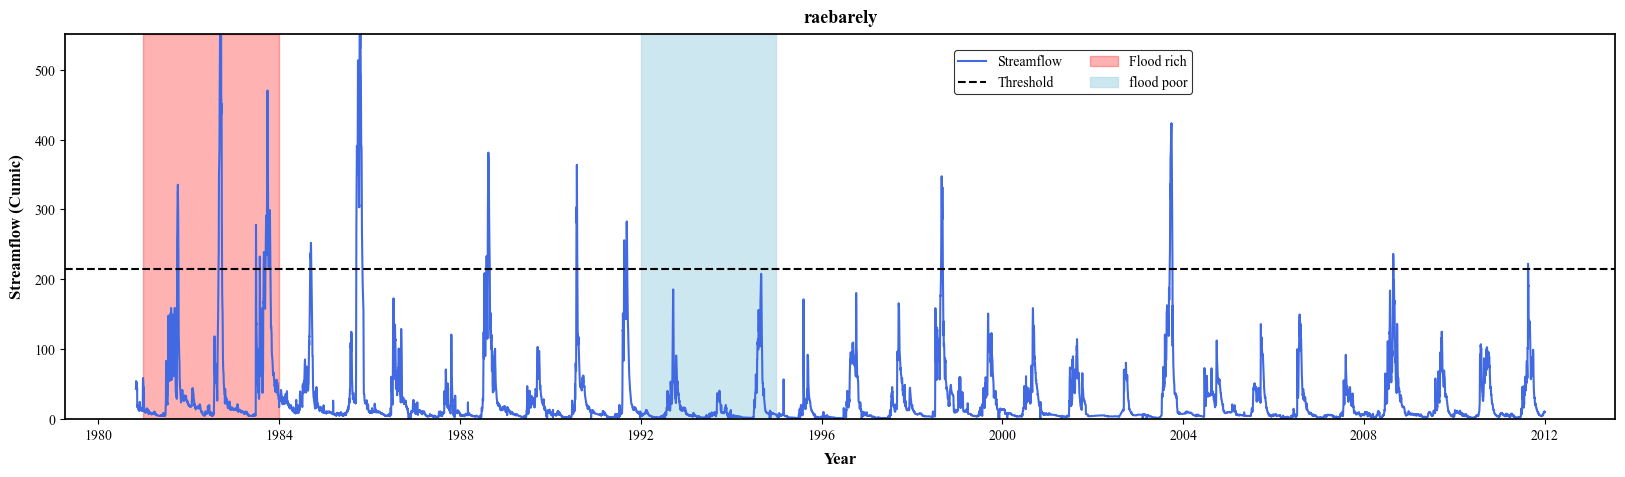

In [4]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.serif"] = "Times New Roman"

gauge=gauge_final[gauge_final['p_value']<0.05] 
gauge.reset_index(drop=True,inplace=True)
g=12

stn=gauge['GaugeID'].values[g]

for g,stn in enumerate(gauge['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) 


    # Create figure and axis
    fig, ax = plt.subplots(figsize=(20, 5))


    [x.set_linewidth(1.25) for x in ax.spines.values()]

    # Plot time series
    ax.plot(data1.index, data1['Streamflow (cumecs)'], linestyle="-", color="royalblue", label="Streamflow")
    #ax.bar(data1.index, data1['Streamflow (cumecs)'], label="Streamflow", width=2)  


    # Add horizontal threshold line
    thr=np.percentile(data1['Streamflow (cumecs)'],98)

    ax.axhline(y=thr, color="black", linestyle="--", label=f"Threshold")

    # flood rich
    strt=flood_rich.loc[stn].astype(float).idxmax()
    end=strt+pd.DateOffset(years=m)
    ax.axvspan(strt, end, color="red", alpha=0.3, label="Flood rich")

    # flood Poor
    strt2=flood_rich.loc[stn].astype(float).idxmin()
    end2=strt2+pd.DateOffset(years=m)
    ax.axvspan(strt2, end2, color="lightblue", alpha=0.6, label="flood poor")



    # Formatting
    ax.set_ylim(0,np.percentile(data1['Streamflow (cumecs)'],99.9))


    ax.set_xlabel('Year',fontsize=12,labelpad=7,weight='bold')
    ax.set_ylabel("Streamflow (Cumic)",fontsize=12,labelpad=7,weight='bold')



    lgnd=plt.legend(loc='center', ncol=2,fontsize=10, bbox_to_anchor=(0.65, 0.9),frameon=True, borderpad=0.32, edgecolor='black')
    frame = lgnd.get_frame()
    frame.set_linewidth(0.8)


    station=gauge.loc[g,'Station']
    ax.set_title(f"{station}",fontsize=13,pad=8,fontname='Times New Roman',weight='bold')

    # Show plot
    plt.savefig(fr'2_Analysis\2_Temperol clustering\Outputs\Flood_rich\{station}.jpeg', bbox_inches='tight',dpi=1000)



'Shirdhon'

In [ ]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.serif"] = "Times New Roman"

sat=xr.open_dataset(f'DATA\sat.nc')
bb_sat=sat['air'].sel(level=2.0,lon=slice(70,100),lat=slice(24,5),time=slice('1980','2020'))
ar_sat=sat['air'].sel(level=2.0,lon=slice(52,78),lat=slice(26,5),time=slice('1980','2020'))

bb_sat=bb_sat-273

# Climatology

bb_sat_c=bb_sat.groupby('time.month').mean().mean(dim=['lon','lat'])
ar_sat_c=ar_sat.groupby('time.month').mean().mean(dim=['lon','lat'])


mth= ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sept", "Oct", "Nov", "Dec"]

# Plot the climatology
fig, ax=plt.subplots(figsize=(7, 4.5),dpi=100) #dimension in inches


#1. Axis boundaryu
ax.plot(mth,bb_sat_c.values,marker="o", color='blue', linestyle='-',label='SAT (Bay of Bengal)')
ax.plot(mth,ar_sat_c.values, color='blue', linestyle='--',label='SAT (Arabian sea)',alpha=0.5)

[x.set_linewidth(1.25) for x in ax.spines.values()]


#2. Axis grids
ax.yaxis.set_minor_locator(plt.MultipleLocator(20)) 

ax.grid(True, color= 'grey', alpha=0.75, linestyle='dotted')
ax.set_ylim(22,33)

#3. Axis label
ax.set_xlabel('Month',fontsize=12,labelpad=7,weight='bold')
ax.set_ylabel('Temperature (\u00B0C)',fontsize=12,labelpad=7,weight='bold')
ax.tick_params(which='major', length=1.5,direction='in',width=1.25,labelsize=12)
ax.tick_params(which='minor', length=1.2,direction='in',width=1)


lgnd=plt.legend(loc='center', ncol=1,fontsize=10, bbox_to_anchor=(0.65, 0.9),frameon=True, borderpad=0.32, edgecolor='black')
frame = lgnd.get_frame()
frame.set_linewidth(0.8)

ax.set_title(f"Domain Averaged Temperature Climatology",fontsize=13,pad=8,fontname='Times New Roman',weight='bold')
#plt.savefig(f'1_assignment/Results/a. globally avragged Climatology of both.png')

# FUNCTIONS

### 1. Station visualization

In [6]:

def Station_Map(data,condition):

    #data=pd.read_csv(r"3_Data\Data_p\2_Station\1_Streamflow_data\data.csv")
    south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')
 
    fig, ax1 = plt.subplots(1, 1, figsize=(6,6), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]

    c1=np.repeat(['Blue'],len(data['Latitude']))
    sc=ax1.scatter(data['Longitude'],data['Latitude'],c='firebrick',s=13,edgecolor='black')

    ax1.text(0.50, 0.95, 'Stations : Full', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')

    ax1.text(0.5, 0.9, f'No of Station : {len(data)}' , fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')


